<a href="https://colab.research.google.com/github/Tienndat2306/TH_DeepLearning_Tuan3/blob/main/ANN_FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nạp thư viện

In [2]:
# Install scikeras as KerasClassifier
!pip install scikeras

In [3]:
# install required libraries
import pandas as pd
import numpy as np
# data visualization packages
import matplotlib.pyplot as plt
# keras packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras. layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras. layers import Dense
from scikeras.wrappers import KerasClassifier
from keras. layers import Dropout
# model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

Tập dữ liệu Fashion MNIST

In [4]:
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion. load_data()
print(X_train.shape, y_train. shape, X_test. shape, y_test. shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Xử lý dữ liệu

In [5]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

minmax = MinMaxScaler()

X_train = minmax. fit_transform(X_train)
X_test = minmax. transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


Trực quan hóa dữ liệu

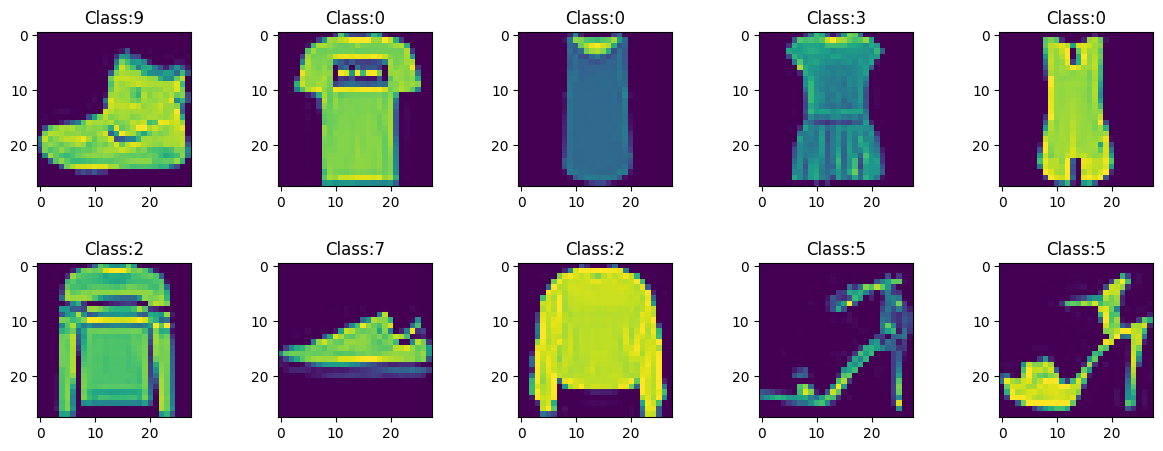

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt. show()

Xây dựng mô hình ANN

In [8]:
#initial ANN model
fashion_model = Sequential()

#add first hidden layer
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

#add output layer
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

#compile neural network
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#model summary
fashion_model. summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện


In [9]:
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8208 - loss: 0.5063 - val_accuracy: 0.8525 - val_loss: 0.3962
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8652 - loss: 0.3716 - val_accuracy: 0.8637 - val_loss: 0.3678
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8778 - loss: 0.3312 - val_accuracy: 0.8693 - val_loss: 0.3612
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8857 - loss: 0.3096 - val_accuracy: 0.8825 - val_loss: 0.3282
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8939 - loss: 0.2891 - val_accuracy: 0.8817 - val_loss: 0.3287
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8986 - loss: 0.2742 - val_accuracy: 0.8788 - val_loss: 0.3346
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9029 - loss: 0.2620 - val_accuracy: 0.8872 - val_loss: 0.3170
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9063 - loss: 0.2509 

Accuracy

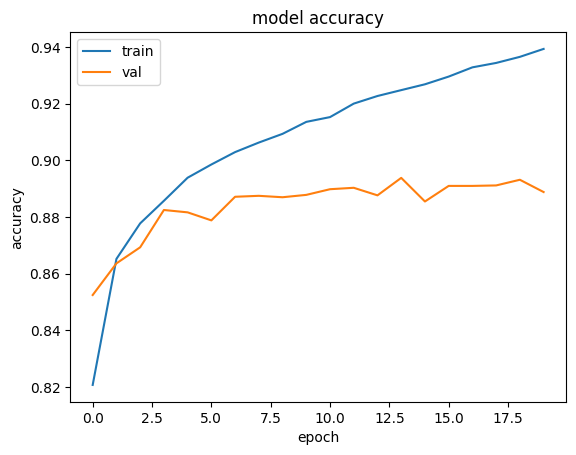

In [10]:
plt.plot(model_fit.history['accuracy' ])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Loss

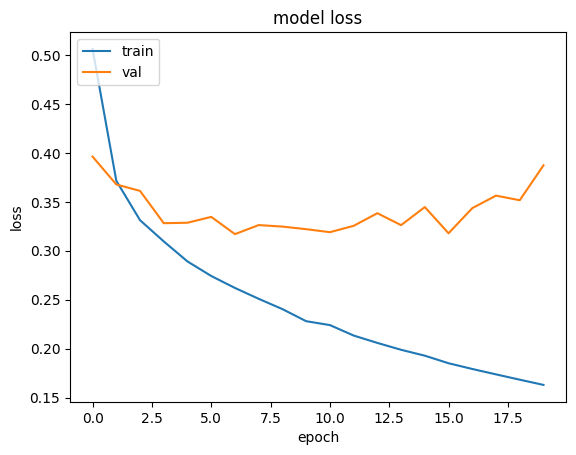

In [12]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss' ])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt. legend(['train', 'val'], loc='upper left')
plt.show()

Dự đoán ảnh mới

In [13]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


Dự đoán trên bộ dữ liệu

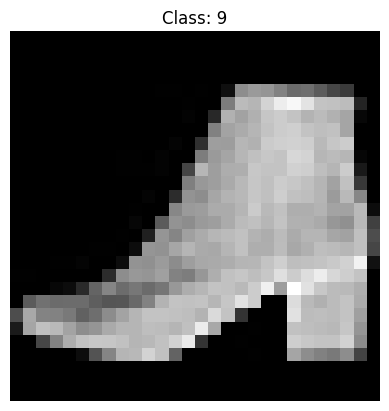

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted result: 9
Real label: 9


In [30]:
index = np.random.randint(0, len(X_test))

image = X_test[index]

label = y_test[index]


plt.imshow(image.reshape(28, 28), cmap='gray')

plt.title(f'Class: {label}')

plt.axis('off')

plt.show()

image_input = image.reshape(1, 784)

prediction = fashion_model.predict(image_input)

predicted_class = np.argmax(prediction)

print("Predicted result:", predicted_class)

print("Real label:", label)